# 2D Ring Empirical experiment from Zhai Dobson Li paper

In this example this is the SDE:

$ dX_t = \left(-4X_t\left(\left\|X_t\right\|^2-1\right)+RX_t\right)dt + \sigma dW_t $

where $R$ is an antisymmetric matrix and $\sigma$ is a constant. In particular $\sigma\in\mathbb{R}$ (or $\sigma \parallel \text{Id}$)

The associated Fokker Planck equation is:

$ u_t = - \sum_i (f_i u)_{x_i} + \frac12\sum_{ij} (\Sigma_{ij}u)_{x_ix_j}$

where $f(x,t)=-4x\left(\left\|x\right\|^2-1\right)+Rx$ and $\Sigma(x,t)=\sigma(x,t)^T\sigma(x,t)$

In the article the author says that the theoretical steady state is:

$u(x) = \frac{1}{K}e^{\alpha V(\left\|x\right\|^2)}$

## Training

We want a neural network with parameters $\theta$ representd by $x\mapsto\tilde{u}(x,\theta)$ such that minimizes:

$$L(\theta) = \frac{1}{N^X}\sum_{i=1}^{N^X}(\mathcal{L}\tilde{u}(x_i,\theta))^2+\frac{1}{N^Y}\sum_{j=1}^{N^Y}(\tilde{u}(y_j,\theta)-v(y_j))^2:=L_1(\theta)+L_2(\theta)$$

where:
- $\theta$ is the set of parameters of the NN
- $x_i\in\mathbb{R}^n$ with $i=1,2,\ldots,N^X$
- $y_j\in\mathbb{R}^n$ with $j=1,2,\dots,N^Y$
- $v(y_j)$ is the solution of the MC approximation.

## Monte Carlo

Here we implement the function $v$, in the paper the authors report the procedure:

- A single trajectory for Euler-Maruyama numerical scheme with:
    - $10^7$ steps
    - the time step size is 0.001
    - empirical probability on a $200\times200$ mesh of the region $D = [−2,2] ×[−2,2]$
    - sampling from this trajectory 

In [1]:
# monte carlo implementation of the example in Zhai et al. (2022)
import numpy as np
from zhai2022.sde import Model
from zhai2022.sde.euler_maruyama import EulerMaruyama

R = np.array([[0,1],[-1,0]])

# Define drift, diffusion, and initial state functions
def drift(X, t):
    return - 4 * (np.linalg.norm(X, axis=-1, keepdims=True)**2-1) * X + np.einsum('ij, sj -> si', R, X)

def diffusion(X, t):
    return np.tile(np.eye(X.shape[1]), (X.shape[0], 1, 1))

def initial_state(n_samples):
    return np.zeros((n_samples, 2))

# Create a Model instance
model = Model(drift, diffusion, initial_state, initial_time=0.0, n_dim=2)

# burn-in: 10sec of real time simulation
dt_schedule = np.ones(int(10/0.001)) * 0.001
euler_maruyama = EulerMaruyama(model, dt_schedule)
X = euler_maruyama.get_end(n_samples=1)  # shape: (1, 2)

# start simulation for 10^7 samples
dt_schedule = np.ones(10**7) * 0.001
def new_init(n_samples):
    return np.ones((n_samples, 2)) * X
model = Model(drift, diffusion, new_init, initial_time=0.0, n_dim=2)
euler_maruyama = EulerMaruyama(model, dt_schedule)
Xtrj = euler_maruyama.get_trajectory(n_samples=1)  # shape: (n_time_steps, 1, n_dim)

The idea is simple:

after a burn-in (in this case with 10sec of real time simulation and starting point in $0$), the authors make a single trajectory with many steps and a long time. Although there is a dependency between one sample and the next, the union of all samples from a long real time (10^4 seconds) trajectory allows us to no longer recognize the trajectory and have samples of the final distribution.

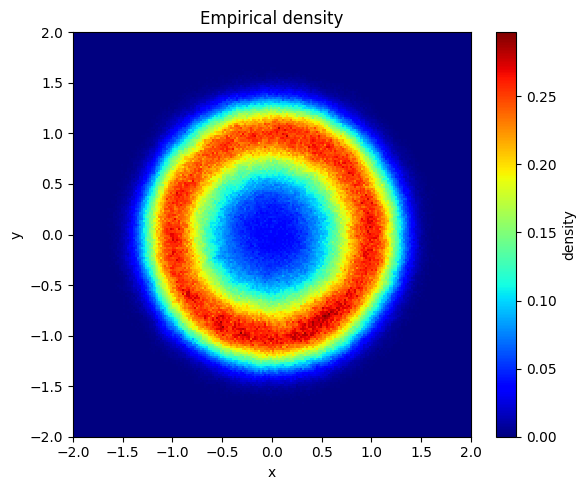

In [2]:
# see density
from matplotlib import pyplot as plt

# compute empirical density
x = Xtrj[:,0,0]
y = Xtrj[:,0,1]

# dominio e griglia
xmin, xmax = -2, 2
ymin, ymax = -2, 2
nx, ny = 200, 200   # come il paper

plt.figure(figsize=(6, 5))
counts, xedges, yedges, img = plt.hist2d(
    x, y,
    bins=[nx, ny],
    range=[[xmin, xmax], [ymin, ymax]],
    density=True,        # normalizza: somma ≈ 1
    cmap="jet",
    cmin=0,
)
plt.colorbar(label="density")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Empirical density")
plt.tight_layout()
plt.show()

In [3]:
def v(vec: np.ndarray):
    # vec has shape N,2
    mask = np.logical_and(
        np.logical_and(vec[:,0]>=xmin, vec[:,0]<xmax),
        np.logical_and(vec[:,1]>=ymin, vec[:,1]<ymax)
    )
    valid_vec = vec[mask]
    ix = np.searchsorted(xedges, valid_vec[:,0], side="right") - 1
    iy = np.searchsorted(yedges, valid_vec[:,1], side="right") - 1

    values = np.empty(vec.shape[0])

    values[mask] = counts[ix,iy]
    values[~mask] = 0.0

    return values

## Linear problem

Then, we have to compute $\mathcal{L}\tilde{u}\left(x,\theta\right)$

Here, I compute $\mathcal{L}(x,t)$ matrix with given model

$ u_t = -\sum_{i} (f_i u)_{x_i} + \sum_{ij} (\Sigma_{ij}u)_{x_ix_j} = \left[\nabla_x^2\cdot\Sigma-\nabla_x \cdot f, 2\nabla_x\cdot\Sigma-f, \Sigma\right]\cdot\left[u,u_x,u_{xx}\right] = \mathcal{L}u$

where:
- $\nabla_x^2\cdot\Sigma:=\sum_{ij} \partial_{x_ix_j}\Sigma_{ij}$
- $\nabla_x\cdot\Sigma:=\left(\nabla_x \cdot \Sigma_{n}\right)_n$

In this case we have:

$u_t = \left[-\nabla_x \cdot f, -f, \Sigma\right]\cdot\left[u,u_x,u_{xx}\right]$

The training requires an extimation of
$$\partial_\theta \mathcal{L}\tilde{u}\left(x,\theta\right) = \partial_\theta \left[\nabla_x^2\cdot\Sigma-\nabla_x \cdot f, 2\nabla_x\cdot\Sigma-f, \Sigma\right]\cdot\left[\tilde{u}_\theta,\nabla_x \tilde{u}_\theta,\nabla_x^2\tilde{u}_\theta\right] = \left[\nabla_x^2\cdot\Sigma-\nabla_x \cdot f, 2\nabla_x\cdot\Sigma-f, \Sigma\right]\cdot\partial_\theta\left[\tilde{u}_\theta,\nabla_x \tilde{u}_\theta,\nabla_x^2\tilde{u}_\theta\right]$$

For a simple implementation we use autograd

### Autograd

Let $x$ be a torch tensor with autograd enabled. In torch, when we use an arithmetic operation the program update the gradient of $x$. An example:

In [23]:
from typing import Callable
import torch


def der(f: Callable[[torch.tensor], torch.tensor], x: torch.tensor, n: int) -> torch.tensor:
    # si assume che la prima dimensione di x sia il batch dimension
    if n == 0:
        return f(x)
    elif n == 1:
        jacobians: torch.tensor = []
        for i in range(x.shape[0]):
            J = torch.autograd.functional.jacobian(
                f, x[i:i+1],  # compute df/dx for the entire batch
                create_graph=True,  # maintain computation graph for higher-order derivatives
                vectorize=True      # process the batch in a vectorized manner
            )
            # x_shape = (1,...)
            # f_shape = (1,...)
            # J shape = f_shape + x_shape
            N = len(x.shape)
            J = J.squeeze(0).squeeze(-N)
            jacobians.append(J)
        return torch.stack(jacobians)
    else:
        return der(
            lambda z: der(f, z, n - 1),
            x, 1
        )

# test:
# dummy: R3 -> R2
def dummy(x: torch.tensor):
    return torch.stack([torch.norm(x, dim=-1)**2, torch.mean(x, dim=-1)], dim=1)

# shape Nx3
x = torch.randn(5, 3, requires_grad=True)

J = der(dummy, x, 1)
# expected shape: Nx2x3
print(J.shape)

# J: R3 -> R(2x3)
H = der(dummy, x, 2)
# expected shape: Nx2x3x3
print(H.shape)


torch.Size([5, 2, 3])
torch.Size([5, 2, 3, 3])


The authors used an MLP defined as follow:

In [24]:
# creo una MLP
from torch import nn

class MLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.Tanh(),
            nn.Linear(16, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 16),
            nn.Tanh(),
            nn.Linear(16, 4),
            nn.Tanh(),
            nn.Linear(4, output_dim),
        )

    def forward(self, x: torch.tensor) -> torch.tensor:
        return self.network(x)

We can compute the derivative respect the input until the second derivative

In [25]:
model = MLP(input_dim=2, output_dim=1)

# example input
x = torch.tensor([[0.5, 0.5], [1.0, 0.0], [0.0, -1.0]], requires_grad=True)

# disable requires_grad for inference
for param in model.parameters():
    param.requires_grad = False

output = model(x)  # output depends on only input x

# compute gradient of output w.r.t. input x
grad_output = der(model, x, 1)
grad_output2 = der(model, x, 2)

print("Gradient of MLP output w.r.t. input x:\n", grad_output.detach().numpy())
print("Hessian of MLP output w.r.t. input x:\n", grad_output2.detach().numpy())

Gradient of MLP output w.r.t. input x:
 [[[-0.0200785  -0.01547753]]

 [[-0.01998434 -0.01730841]]

 [[-0.015365   -0.01399171]]]
Hessian of MLP output w.r.t. input x:
 [[[[ 0.00325832  0.00417614]
   [ 0.00417614  0.00813097]]]


 [[[ 0.0051939   0.00443475]
   [ 0.00443475  0.0065348 ]]]


 [[[-0.01022661 -0.00549143]
   [-0.00549143 -0.00805614]]]]


In this case we have:
- $ f = -4x\left(\left\|x\right\|^2-1\right)+Rx $
- $\nabla_x\cdot f = \nabla_x\cdot\left(-4x\left(\left\|x\right\|^2-1\right)\right) + \nabla_x\cdot\left(Rx\right) = \nabla_x \left(-4\left(\left\|x\right\|^2-1\right)\right)\cdot x + \left(-4\left(\left\|x\right\|^2-1\right)\right)\nabla_x\cdot x + \text{Tr}\left[R\right] = -8x\cdot x -4d\left(\left\|x\right\|^2-1\right) = 4\left(d-(2+d)\left\|x\right\|^2\right)$

So, in this example:
$\mathcal{L}\tilde{u} = \left[-\nabla_x \cdot f, -f, \Sigma\right]\cdot\left[\tilde{u},\tilde{u}_x,\tilde{u}_{xx}\right]$

In [ ]:
R = torch.tensor([[0,1,2],[-1,0,1],[-2,-1,0]], dtype=torch.float32)

def f(x: torch.tensor):
    return -4*x*(torch.norm(x, dim=-1, keepdim=True)**2 - 1) + torch.einsum('ij, sj -> si', R, x)

df = der(f, torch.tensor([[1.0, 0.0, -1.0]]), 1)  # first derivative
divf = torch.trace(df[0])  # divergence at the point [1.0, 0.0, -1.0]
print("Divergence of f at [1.0, 0.0, -1.0]:", divf.item())
# theoretical value should be 4(3-5*|x|^2) = 4(3-5*2) = 4*(-7) = -28

Divergence of f at [1.0, 0.0, -1.0]: -27.999998092651367


In [29]:
# return u_t of the model with dependecency on theta (parameters of the model)
def L(x: torch.tensor, model: nn.Module):
    # assertion: model.requires_grad_is True
    # x has shape (N, d)
    # compute u
    u = model(x)  # shape: (N, 1)
    # compute du/dx
    du_dx = der(model, x, 1)  # shape: (N, 1, d)
    # compute d^2u/dx^2
    d2u_dx2 = der(model, x, 2)  # shape: (N, 1, d, d)
    # compute f(x)
    R = torch.tensor([[0,1],[-1,0]], dtype=torch.float32)
    f_x = -4*x*(torch.norm(x, dim=-1, keepdim=True)**2 - 1) + torch.einsum('ij, sj -> si', R, x)  # shape: (N, d)
    # compute the divergence of f
    divf = 4*(x.shape[1]-(2+x.shape[1]))*torch.norm(x, dim=-1)**2  # shape: (N,)
    # -divf * u + (-f) * du/dx + du2/dx2
    # vectorized computation
    term1 = (-divf * u)[:,0]  # shape: (N,)
    term2 = -torch.einsum('ni, ni -> n', f_x, du_dx[:,0,:])  # shape: (N,)
    term3 = torch.sum(d2u_dx2[:,0,:,:].reshape(d2u_dx2.shape[0], -1), dim=(-1))  # shape: (N,)
    result = term1 + term2 + term3  # shape: (N,)
    return result

# test L
u_t = L(torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, -1.0]]), model)  # shape: (N,)  (N=3)
print(u_t)


tensor([-2.4274, -2.3610, -2.3465], grad_fn=<AddBackward0>)
